## importattion des librairies necessaires

In [1]:
%matplotlib inline
#! pip install python-igraph --no-binary :all:
#! pip install splot

import seaborn as sns
import math 
import splot
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

## Recuperation des données sur retrans et le packet loss puis insertion dans un csv

In [2]:
import csv
# Step 1: Parse raw output
output_txt = "/home/gyongayo/Bureau/New_data/6videos/raw3.txt"
output_csv = "stats.csv"
total_tcp = 0
retrans = 0
lost = 0
rows = []
interval_sec = 1 
with open(output_txt, "r") as f:
          for line in f:
                if "<>" in line:
                    clean_line = re.sub(r"[|]", "", line).strip()
                    tokens = re.split(r"\s+", clean_line)
                    if len(tokens) < 8:
                        continue  # skip incomplete lines

                    interval = f"{tokens[0]}-{tokens[2]}"

            # Extract frames and bytes by positions from the end
                    retrans_bytes = tokens[-1]
                    retrans_frames = tokens[-2]
                    lost_bytes = tokens[-3]
                    lost_frames = tokens[-4]
                    total_bytes = tokens[-5]
                    total_frames = tokens[-6]

            # Compute throughput and loss %
                    throughput = int(total_bytes) / interval_sec
                    loss_percent = ((int(lost_frames) + int(retrans_frames)) / int(total_frames) * 100) if int(total_frames) > 0 else 0
                    loss_percent2 = (int(lost_frames) / int(total_frames) * 100) if int(total_frames) > 0 else 0


                    rows.append([interval, total_frames, lost_frames, lost_bytes, retrans_frames, retrans_bytes, throughput, loss_percent2, loss_percent])

                    #loss_percent = (lost / total_tcp * 100) if total_tcp > 0 else 0
                    

# Step 2: Write CSV
header = ["Interval", "toatl_packet","Loss_packet", "Loss_Bytes", "Retrans_Frames", "Retrans_Bytes", "Throughput_Bytes_per_sec", "loss_percent","loss_percent2"]
with open(output_csv, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(rows)

print(f"CSV saved to {output_csv}")             

CSV saved to stats.csv


### lecture des csv

In [3]:
df = pd.read_csv('/home/gyongayo/Bureau/New_data/6videos/cgroup_metrics_3591ea9fe1a53e7bc10712ad493ad398be6ad23ebdb6d30604376a76d5fd9ebc_20250916_110157.csv')
df['cpu_pct'] = df['cpu_pct'].astype(float)
df['mem_pct'] = df['mem_pct'].astype(float)
df['cpu_pct_core'] = df['cpu_pct_core'].astype(float)
df['rss_pct'] = df['rss_pct'].astype(float)
df['timestamp'] = pd.to_datetime(df['timestamp'], format="%Y-%m-%d_%H:%M:%S.%f")
df['heure'] = df['timestamp'].dt.strftime('%H:%M:%S.%f')
df.head()

,timestamp,container_id,cpu_usage_ns,cpu_pct,cpu_pct_core,mem_usage_bytes,mem_limit_bytes,mem_pct,mem_max,rss,rss_pct,heure
0,2025-09-16 11:01:57.538430,3591ea9fe1a53e7bc10712ad493ad398be6ad23ebdb6d3...,281113789973,6.67,1.67,20606976,1004146688,2.05,41181184,17932288,1.79,11:01:57.538430
1,2025-09-16 11:01:57.826303,3591ea9fe1a53e7bc10712ad493ad398be6ad23ebdb6d3...,281118116332,1.50,0.38,20606976,1004146688,2.05,41181184,17932288,1.79,11:01:57.826303
2,2025-09-16 11:01:58.117430,3591ea9fe1a53e7bc10712ad493ad398be6ad23ebdb6d3...,281122626909,1.55,0.39,20676608,1004146688,2.06,41181184,17932288,1.79,11:01:58.117430
3,2025-09-16 11:01:58.407582,3591ea9fe1a53e7bc10712ad493ad398be6ad23ebdb6d3...,281135279032,4.37,1.09,20709376,1004146688,2.06,41181184,17932288,1.79,11:01:58.407582
4,2025-09-16 11:01:58.701835,3591ea9fe1a53e7bc10712ad493ad398be6ad23ebdb6d3...,281157414352,7.52,1.88,21069824,1004146688,2.10,41181184,17932288,1.79,11:01:58.701835


In [4]:
import time
data = pd.read_csv('/home/gyongayo/Bureau/New_data/6videos/pc_net.csv')

data['timestamp'] = pd.to_datetime(data['timestamp'], unit='s')

# Si tu veux seulement afficher HH:MM:SS
data['heure'] = data['timestamp'].dt.strftime("%H:%M:%S")

data

,timestamp,tx_kbps,rx_kbps,throughput_kbps,heure
0,2025-09-16 11:02:00.177367808,4.73,20.09,24.83,11:02:00
1,2025-09-16 11:02:01.177870592,1.85,6.30,8.15,11:02:01
2,2025-09-16 11:02:02.178691072,1.02,5.65,6.67,11:02:02
3,2025-09-16 11:02:03.179168000,74.25,2361.82,2436.07,11:02:03
4,2025-09-16 11:02:04.179526144,155.19,5760.52,5915.70,11:02:04
...,...,...,...,...,...
383,2025-09-16 11:08:23.612424704,0.00,0.00,0.00,11:08:23
384,2025-09-16 11:08:24.613538048,0.00,0.00,0.00,11:08:24
385,2025-09-16 11:08:25.614724864,0.01,0.00,0.01,11:08:25
386,2025-09-16 11:08:26.615601664,0.23,0.43,0.67,11:08:26


In [5]:
dataf = pd.read_csv('stats.csv')
dataf

,Interval,toatl_packet,Loss_packet,Loss_Bytes,Retrans_Frames,Retrans_Bytes,Throughput_Bytes_per_sec,loss_percent,loss_percent2
0,0-1,26,1,150,0,0,3541.0,3.846154,3.846154
1,1-2,3690,48,73512,2,1528,4381134.0,1.300813,1.355014
2,2-3,1560,27,41234,12,14846,1556014.0,1.730769,2.500000
3,3-4,2122,30,46170,3,4398,2352146.0,1.413761,1.555137
4,4-5,177,2,1608,0,0,76711.0,1.129944,1.129944
...,...,...,...,...,...,...,...,...,...
297,297-298,14,0,0,0,0,2432.0,0.000000,0.000000
298,298-299,16,0,0,0,0,2276.0,0.000000,0.000000
299,299-300,23,0,0,0,0,4238.0,0.000000,0.000000
300,300-301,13,0,0,0,0,2134.0,0.000000,0.000000


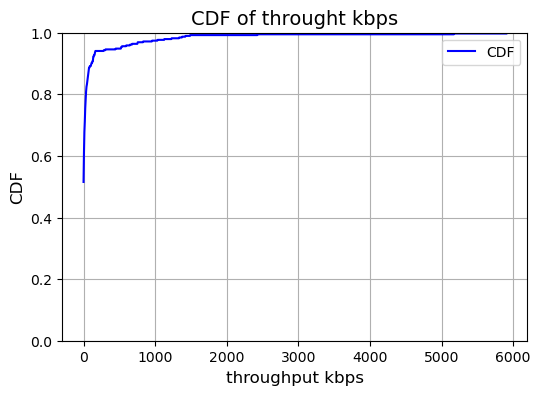

In [6]:
# Calcul de la CDF
hist, bin_edges = np.histogram(data['throughput_kbps'], bins=1000, density=True)
cdf = np.cumsum(hist)
cdf = cdf / cdf[-1]  # Normalisation pour que la dernière valeur soit 1

# Détection de la zone où la CDF devient constante
# On trouve le premier point où la CDF atteint 1
first_constant_index = np.argmax(cdf == 1)  

# Garder seulement les valeurs jusqu'à ce point (en supprimant la zone horizontale et le saut)
x_filtered = bin_edges[:-1][:first_constant_index]
y_filtered = cdf[:first_constant_index]

# Tracé du graphique
plt.figure(figsize=(6, 4))
plt.plot(x_filtered, y_filtered, linewidth=1.5, label="CDF", color="b")

# Échelle logarithmique sur l'axe X
#plt.xscale("log")

# Titres et labels
plt.xlabel("throughput kbps", fontsize=12)
plt.ylabel("CDF", fontsize=12)
plt.title("CDF of throught kbps", fontsize=14)

# Grille et ajustements des axes
plt.grid(True)
plt.xticks(fontsize=10)
plt.yticks(np.arange(0, 1.1, 0.2), fontsize=10)
plt.ylim(0, 1)

# Légende
plt.legend(fontsize=10)

# Sauvegarde en haute qualité
plt.savefig("CDF_throughput.png", bbox_inches="tight", pad_inches=0.1, dpi=300)

# Affichage
plt.show()

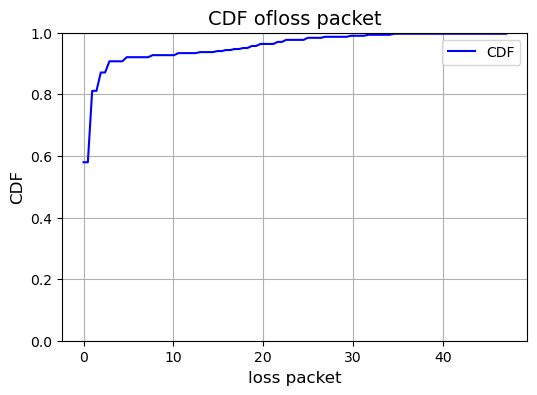

In [7]:
# Calcul de la CDF
hist, bin_edges = np.histogram(dataf['Loss_packet'], bins=100, density=True)
cdf = np.cumsum(hist)
cdf = cdf / cdf[-1]  # Normalisation pour que la dernière valeur soit 1

# Détection de la zone où la CDF devient constante
# On trouve le premier point où la CDF atteint 1
first_constant_index = np.argmax(cdf == 1)  

# Garder seulement les valeurs jusqu'à ce point (en supprimant la zone horizontale et le saut)
x_filtered = bin_edges[:-1][:first_constant_index]
y_filtered = cdf[:first_constant_index]

# Tracé du graphique
plt.figure(figsize=(6, 4))
plt.plot(x_filtered, y_filtered, linewidth=1.5, label="CDF", color="b")

# Échelle logarithmique sur l'axe X
#plt.xscale("log")

# Titres et labels
plt.xlabel("loss packet", fontsize=12)
plt.ylabel("CDF", fontsize=12)
plt.title("CDF ofloss packet", fontsize=14)

# Grille et ajustements des axes
plt.grid(True)
plt.xticks(fontsize=10)
plt.yticks(np.arange(0, 1.1, 0.2), fontsize=10)
plt.ylim(0, 1)

# Légende
plt.legend(fontsize=10)

# Sauvegarde en haute qualité
plt.savefig("CDF_lost_segment.png", bbox_inches="tight", pad_inches=0.1, dpi=300)

# Affichage
plt.show()

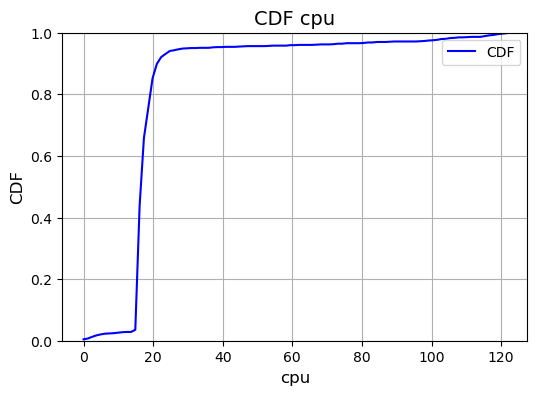

In [8]:
# Calcul de la CDF
hist, bin_edges = np.histogram(df['cpu_pct'], bins=100, density=True)
cdf = np.cumsum(hist)
cdf = cdf / cdf[-1]  # Normalisation pour que la dernière valeur soit 1

# Détection de la zone où la CDF devient constante
# On trouve le premier point où la CDF atteint 1
first_constant_index = np.argmax(cdf == 1)  

# Garder seulement les valeurs jusqu'à ce point (en supprimant la zone horizontale et le saut)
x_filtered = bin_edges[:-1][:first_constant_index]
y_filtered = cdf[:first_constant_index]

# Tracé du graphique
plt.figure(figsize=(6, 4))
plt.plot(x_filtered, y_filtered, linewidth=1.5, label="CDF", color="b")

# Échelle logarithmique sur l'axe X
#plt.xscale("log")

# Titres et labels
plt.xlabel("cpu", fontsize=12)
plt.ylabel("CDF", fontsize=12)
plt.title("CDF cpu", fontsize=14)

# Grille et ajustements des axes
plt.grid(True)
plt.xticks(fontsize=10)
plt.yticks(np.arange(0, 1.1, 0.2), fontsize=10)
plt.ylim(0, 1)

# Légende
plt.legend(fontsize=10)

# Sauvegarde en haute qualité
plt.savefig("CDF_cpu.png", bbox_inches="tight", pad_inches=0.1, dpi=300)

# Affichage
plt.show()

In [9]:
df['heure'] = df['timestamp'].dt.strftime("%H:%M:%S")
df

,timestamp,container_id,cpu_usage_ns,cpu_pct,cpu_pct_core,mem_usage_bytes,mem_limit_bytes,mem_pct,mem_max,rss,rss_pct,heure
0,2025-09-16 11:01:57.538430,3591ea9fe1a53e7bc10712ad493ad398be6ad23ebdb6d3...,281113789973,6.67,1.67,20606976,1004146688,2.05,41181184,17932288,1.79,11:01:57
1,2025-09-16 11:01:57.826303,3591ea9fe1a53e7bc10712ad493ad398be6ad23ebdb6d3...,281118116332,1.50,0.38,20606976,1004146688,2.05,41181184,17932288,1.79,11:01:57
2,2025-09-16 11:01:58.117430,3591ea9fe1a53e7bc10712ad493ad398be6ad23ebdb6d3...,281122626909,1.55,0.39,20676608,1004146688,2.06,41181184,17932288,1.79,11:01:58
3,2025-09-16 11:01:58.407582,3591ea9fe1a53e7bc10712ad493ad398be6ad23ebdb6d3...,281135279032,4.37,1.09,20709376,1004146688,2.06,41181184,17932288,1.79,11:01:58
4,2025-09-16 11:01:58.701835,3591ea9fe1a53e7bc10712ad493ad398be6ad23ebdb6d3...,281157414352,7.52,1.88,21069824,1004146688,2.10,41181184,17932288,1.79,11:01:58
...,...,...,...,...,...,...,...,...,...,...,...,...
1260,2025-09-16 11:08:33.503092,3591ea9fe1a53e7bc10712ad493ad398be6ad23ebdb6d3...,368686221230,16.97,4.24,41918464,1004146688,4.17,48422912,17915904,1.78,11:08:33
1261,2025-09-16 11:08:33.799325,3591ea9fe1a53e7bc10712ad493ad398be6ad23ebdb6d3...,368738393724,17.59,4.40,41656320,1004146688,4.15,48422912,17915904,1.78,11:08:33
1262,2025-09-16 11:08:34.094115,3591ea9fe1a53e7bc10712ad493ad398be6ad23ebdb6d3...,368788099348,16.90,4.23,41656320,1004146688,4.15,48422912,17915904,1.78,11:08:34
1263,2025-09-16 11:08:34.404639,3591ea9fe1a53e7bc10712ad493ad398be6ad23ebdb6d3...,368845518324,17.62,4.41,41922560,1004146688,4.17,48422912,17915904,1.78,11:08:34


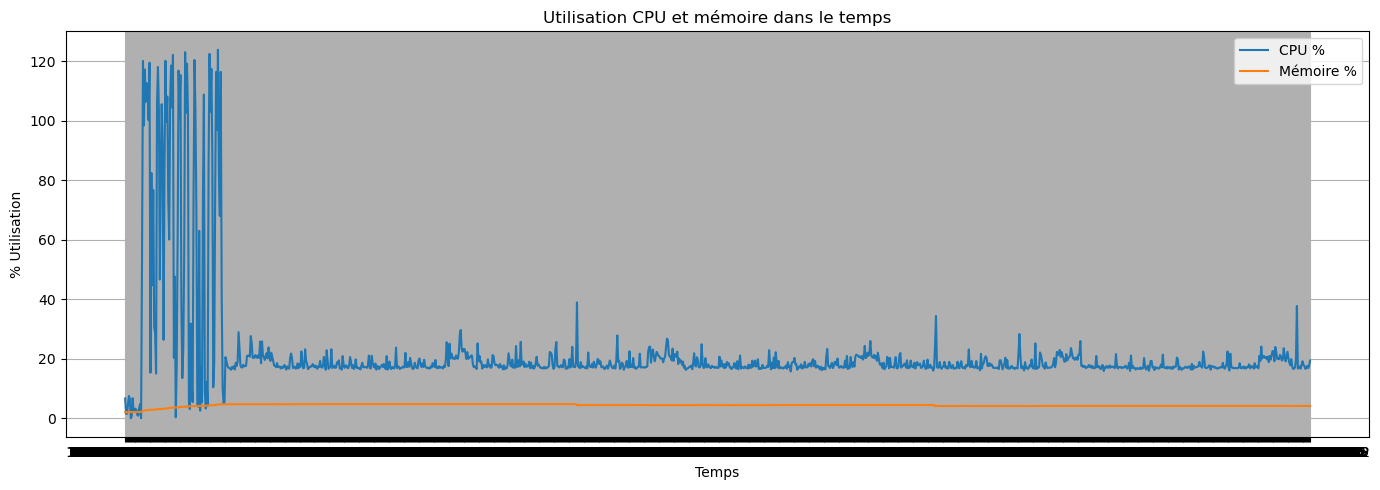

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(df['heure'], df['cpu_pct'], label='CPU %')
plt.plot(df['heure'], df['mem_pct'], label='Mémoire %')
plt.title("Utilisation CPU et mémoire dans le temps")
plt.xlabel("Temps")
plt.ylabel("% Utilisation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("use_cpu_mem_time.png", bbox_inches="tight", pad_inches=0.1, dpi=300)
plt.show()

In [10]:
merged = pd.merge(df, data, on="heure")
merged

,timestamp_x,container_id,cpu_usage_ns,cpu_pct,cpu_pct_core,mem_usage_bytes,mem_limit_bytes,mem_pct,mem_max,rss,rss_pct,heure,timestamp_y,tx_kbps,rx_kbps,throughput_kbps


In [11]:
new_data = merged.drop(columns=["timestamp_x", "timestamp_y"], errors="ignore")
new_data

,container_id,cpu_usage_ns,cpu_pct,cpu_pct_core,mem_usage_bytes,mem_limit_bytes,mem_pct,mem_max,rss,rss_pct,heure,tx_kbps,rx_kbps,throughput_kbps


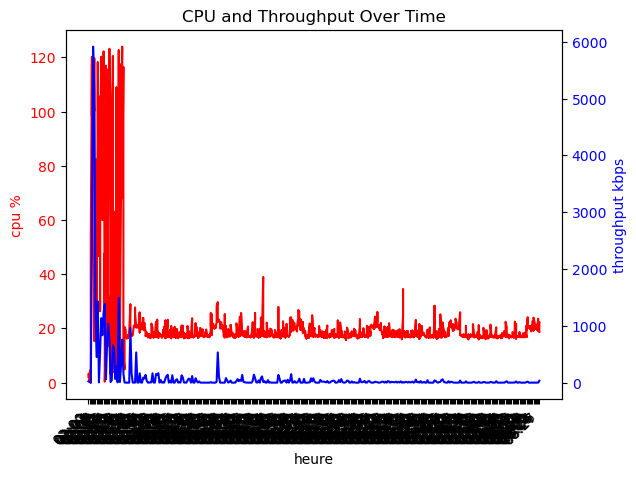

In [24]:
fig, ax1 = plt.subplots() 

ax1.set_xlabel('heure') 
ax1.set_ylabel('cpu %', color = 'red') 
ax1.plot(new_data['heure'].str[-5:], new_data['cpu_pct'], color = 'red') 
ax1.tick_params(axis ='y', labelcolor = 'red') 
  
# Adding Twin Axes

ax2 = ax1.twinx() 
  
ax2.set_ylabel('throughput kbps', color = 'blue') 
ax2.plot(new_data['heure'].str[-5:], new_data['throughput_kbps'], color = 'blue') 
ax2.tick_params(axis ='y', labelcolor = 'blue') 
# Rotation des labels de l'axe X


plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")
 
plt.title("CPU and Throughput Over Time")
# Show plot

plt.show()

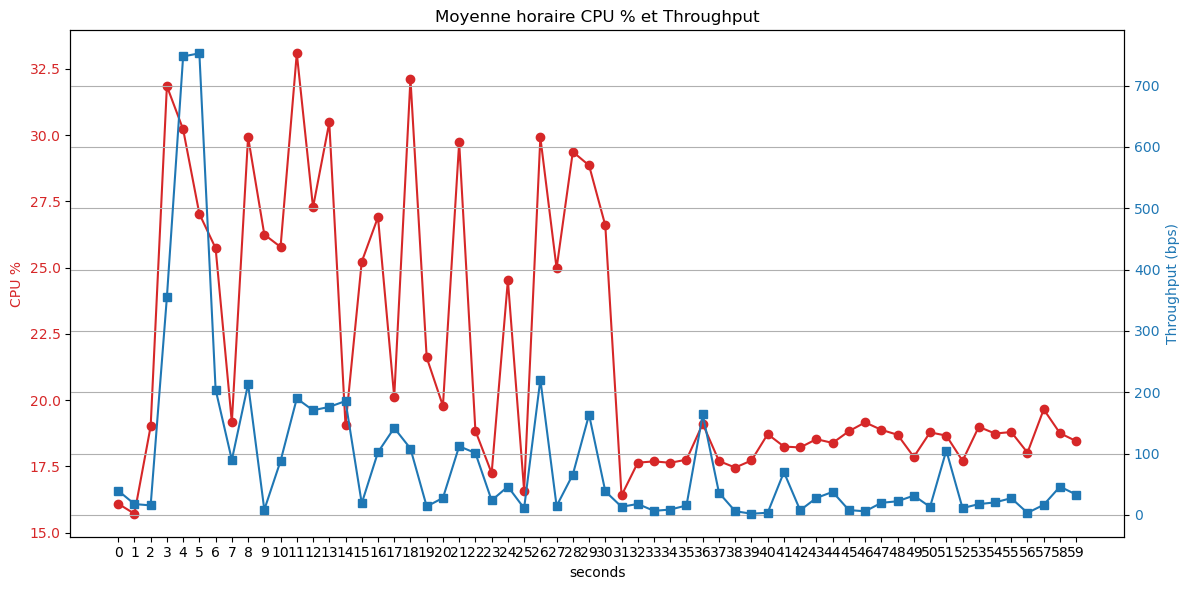

In [ ]:
import matplotlib.pyplot as plt

# Supposons que tu as déjà ton dataframe hourly_avg avec les colonnes :
# 'hour', 'cpu %', 'throughput_bps'

new_data['s'] = new_data['heure'].str.split(':').str[-1].astype(int)
hourly_avg = new_data.groupby('s')[['cpu_pct', 'throughput_kbps']].mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Axe pour le CPU %
color = 'tab:red'
ax1.set_xlabel('seconds')
ax1.set_ylabel('CPU %', color=color)
ax1.plot(hourly_avg.index, hourly_avg['cpu_pct'], color=color, marker='o', label='CPU %')
ax1.tick_params(axis='y', labelcolor=color)

# Deuxième axe Y pour le throughput
ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Throughput (kbps)', color=color)
ax2.plot(hourly_avg.index, hourly_avg['throughput_kbps'], color=color, marker='s', label='Throughput')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Moyenne CPU % et Throughput par seconds")
plt.xticks(hourly_avg.index)
plt.grid(True)
plt.tight_layout()
lt.savefig("cpu_throughput_mean.png", bbox_inches="tight", pad_inches=0.1, dpi=300)
plt.show()

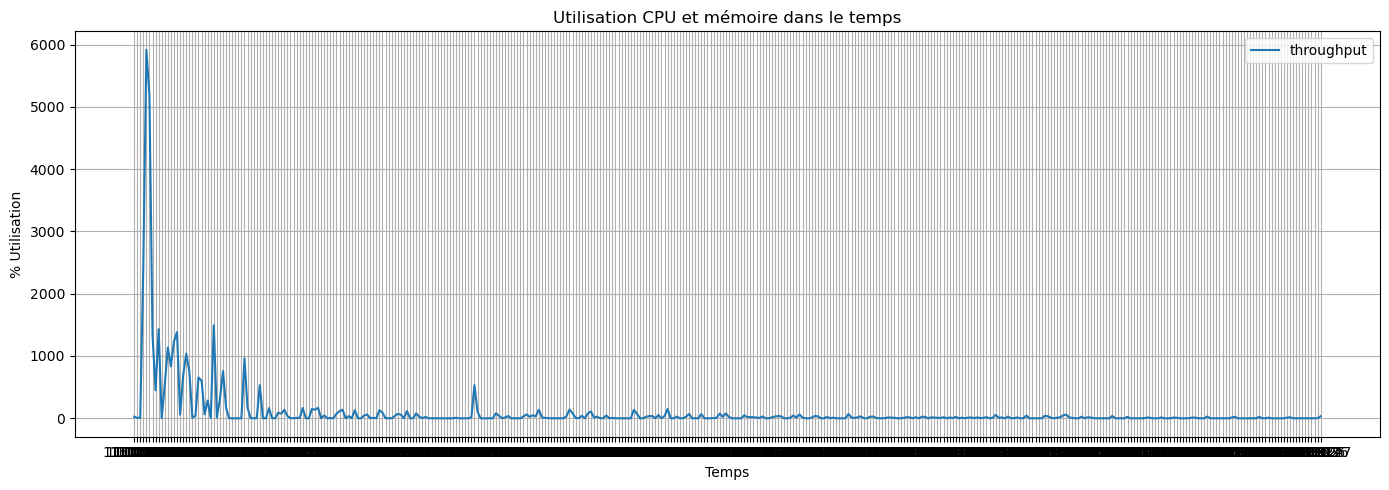

In [8]:
plt.figure(figsize=(14, 5))
plt.plot(data['heure'], data['throughput_kbps'], label='throughput')
plt.title("Utilisation CPU et mémoire dans le temps")
plt.xlabel("Temps")
plt.ylabel("% Utilisation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("use_cpu_mem_time.png", bbox_inches="tight", pad_inches=0.1, dpi=300)
plt.show()

In [ ]:
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
fig, ax1 = plt.subplots(figsize=(12, 6)) 

ax1.set_xlabel('heure') 
ax1.set_ylabel('cpu %', color = 'red') 
ax1.plot(df['heure'], df['cpu_pct'], color = 'red') 
ax1.yaxis.set_major_locator(ticker.MultipleLocator(10))
ax1.tick_params(axis ='y', labelcolor = 'red') 

# Rotation des labels de l'axe X
ax1.xaxis.set_major_locator(mdates.SecondLocator(interval=35))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S.%f'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")

# Adding Twin Axes
plt.tight_layout() 
ax2 = ax1.twinx() 
  
ax2.set_ylabel('mem %', color = 'blue') 
ax2.plot(df['timestamp'], df['mem_pct'], color = 'blue') 
ax2.tick_params(axis ='y', labelcolor = 'blue') 

plt.title("CPU and MEM Over Time")
# Show plot

plt.show()

Locator attempting to generate 1078025 ticks ([-19.84982638888889, ..., 416.8497106481482]), which exceeds Locator.MAXTICKS (1000).


KeyboardInterrupt: 

In [ ]:
# Moyennes par heure de la journée
df['hour'] = df.index.hour
hourly_avg = df.groupby('hour')[['cpu %', 'mem %']].mean()

hourly_avg.plot(kind='bar', figsize=(12, 6))
plt.title("Utilisation moyenne CPU/Mémoire par heure")
plt.ylabel("%")
plt.grid(True)
plt.tight_layout()
plt.savefig("use_mean_cpu_mem.png", bbox_inches="tight", pad_inches=0.1, dpi=300)
plt.show()

In [ ]:
fig, ax1 = plt.subplots() 

ax1.set_xlabel('#inference') 
ax1.set_ylabel('cpu mean (%)', color = 'red') 
ax1.plot(data['inference'], data['cpu_mean'], color = 'red') 
ax1.tick_params(axis ='y', labelcolor = 'red') 
ax1.xaxis.set_major_locator(ticker.MultipleLocator(10))
plt.xticks(rotation=45)
plt.tight_layout()  
plt.title("variation de la charge cpu mean")
# Show plot
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Supposons que seconds_avg est prêt

fig, ax1 = plt.subplots(figsize=(14, 7))


# Grouper par secondes et calculer la moyenne de chaque métrique
seconds_avg = dat.groupby('hour')[['cpu %', 'mem %', 'throughput_bps']].mean()


width = 0.35  # largeur des barres
ind = np.arange(len(seconds_avg))  # positions sur l'axe x (0..59 secondes)

# Barres CPU % et Mémoire %
bar1 = ax1.bar(ind - width/2, seconds_avg['cpu %'], width, label='CPU %', color='red', alpha=0.7)
bar2 = ax1.bar(ind + width/2, seconds_avg['mem %'], width, label='Mémoire %', color='green', alpha=0.7)

ax1.set_xlabel('Seconds')
ax1.set_ylabel('% Utilisation (CPU & Mémoire)', color='black')
ax1.set_xticks(ind)
ax1.set_xticklabels(seconds_avg.index)
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, axis='y')

# Axe secondaire pour throughput
ax2 = ax1.twinx()
bar3 = ax2.bar(ind, seconds_avg['throughput_bps'], width/3, label='Throughput (bps)', color='blue', alpha=0.5)

ax2.set_ylabel('Throughput (bps)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Légende combinée
bars = bar1 + bar2 + bar3
labels = [b.get_label() for b in bars]
plt.legend(bars, labels,loc='upper left')

plt.title("CPU %, Mémoire % et Throughput moyens par seconde")
plt.tight_layout()
#plt.savefig("cpu_mem_throughput_seconds_bar.png", bbox_inches="tight", pad_inches=0.1, dpi=300)
plt.show()